# Prior Sampling with a Uniform Distribution 
Creating prior samples from a uniform distribution with expanded bounds (and using rho instead of alpha/(\sqrt{N})

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng
import GFmodel as gf
import PlotClouds as PlotClouds
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

In [2]:
import sys
import os

# Remonte d'un dossier vers la racine du projet (le parent)
chemin_racine = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Ajoute ce chemin s'il n'y est pas déjà
if chemin_racine not in sys.path:
    sys.path.append(chemin_racine)

In [3]:
def test_fun(num_s):
    samples = np.zeros((num_s,4))
    count = 0
    for i in range(0, num_s): 
        uniform = np.zeros(4)
        uniform[0] = np.random.uniform(0, 4000) #H_0
        uniform[1] = np.random.uniform(0, 720) #tau in minutes
        uniform[2] = np.random.uniform(0, 720) #T 
        uniform[3] = np.random.uniform(0, 1e-2/1440) #rho
        if gf.prior(uniform) == 1: 
            samples[count] = uniform
            count = count + 1
            print("The number of samples is:", count, 'and total iterations is', i, end = "\r")
    return samples[:count]

In [ ]:
# num_s = 10000
# my_samples = test_fun(num_s)
file_path = "/gf_model/files/prior/exp03_
my_samples = np.loadtxt((chemin_racine + file_path + " delimiter = ',') 
for ii in range(1, 10):
    add_samples = np.loadtxt((chemin_racine + file_path + "prior_samples_%d.txt") %ii, delimiter = ',') 
    my_samples = np.concatenate((my_samples, add_samples), axis = 0)

np.savetxt((chemin_racine + "/gf_model/files/prior/prior_samples_exp03.txt"), my_samples, delimiter = ',') 

In [29]:
def norm(x):
    return np.sqrt(np.sum(x**2))

dmin = np.inf
samp = my_samples[68]
isamp = 68
for i, sample in enumerate(my_samples):
    d = norm(sample - [3.58320864e+03, 4.22794102e+02, 8.33435208e+01, 1.54198860e-08])
    if d < dmin:
        dmin = d
        samp = sample
        isamp = i
print("Closest sample:", samp, isamp)

Closest sample: [3.58560205e+03 4.29057121e+02 9.29445997e+01 9.32791474e-09] 115841


[3.58560205e+03 4.29057121e+02 9.29445997e+01 9.32791474e-09]


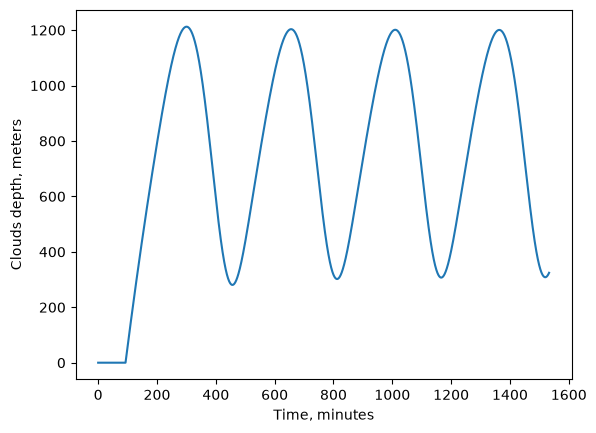

In [30]:
samp = my_samples[115841]
print(samp)
dt = 0.1
solve_time = 1440
Hint = 0.1*np.ones(len(np.arange(0,samp[2]+dt,dt)))
check_oscillations = gf.dim_RK4(samp[0], samp[1], samp[2], samp[3], 
                                Hint, solve_time, dt)
plt.figure()
plt.plot(np.arange(0, solve_time + samp[2], dt), check_oscillations)
plt.xlabel("Time, minutes")
plt.ylabel("Clouds depth, meters")
plt.show()


In [5]:
import numpy as np
from matplotlib import colormaps

# 1. On récupère la colormap via l'interface moderne et on l'échantillonne
magma = colormaps['magma'].resampled(256)

# 2. On extrait les couleurs
newcolors = magma(np.linspace(0, 1, 256))

# 3. On applique vos modifications (ici, remplacer par du blanc/rose)
pink = np.array([1, 1, 1, 1])
newcolors[:10, :] = pink
newcmp = ListedColormap(newcolors)

In [6]:
# plot_concat = np.loadtxt('files/prior_exp/all_uniform_new_prior_sam.txt', delimiter = ',')
plot_concat = my_samples
print(plot_concat.shape)
plot_concat[:,3] = plot_concat[:,3]*1440
plot_concat[:,0] = plot_concat[:,0]/1000

plot_concat = plot_concat.reshape((1, len(plot_concat[:,0]), 4))

(164943, 4)


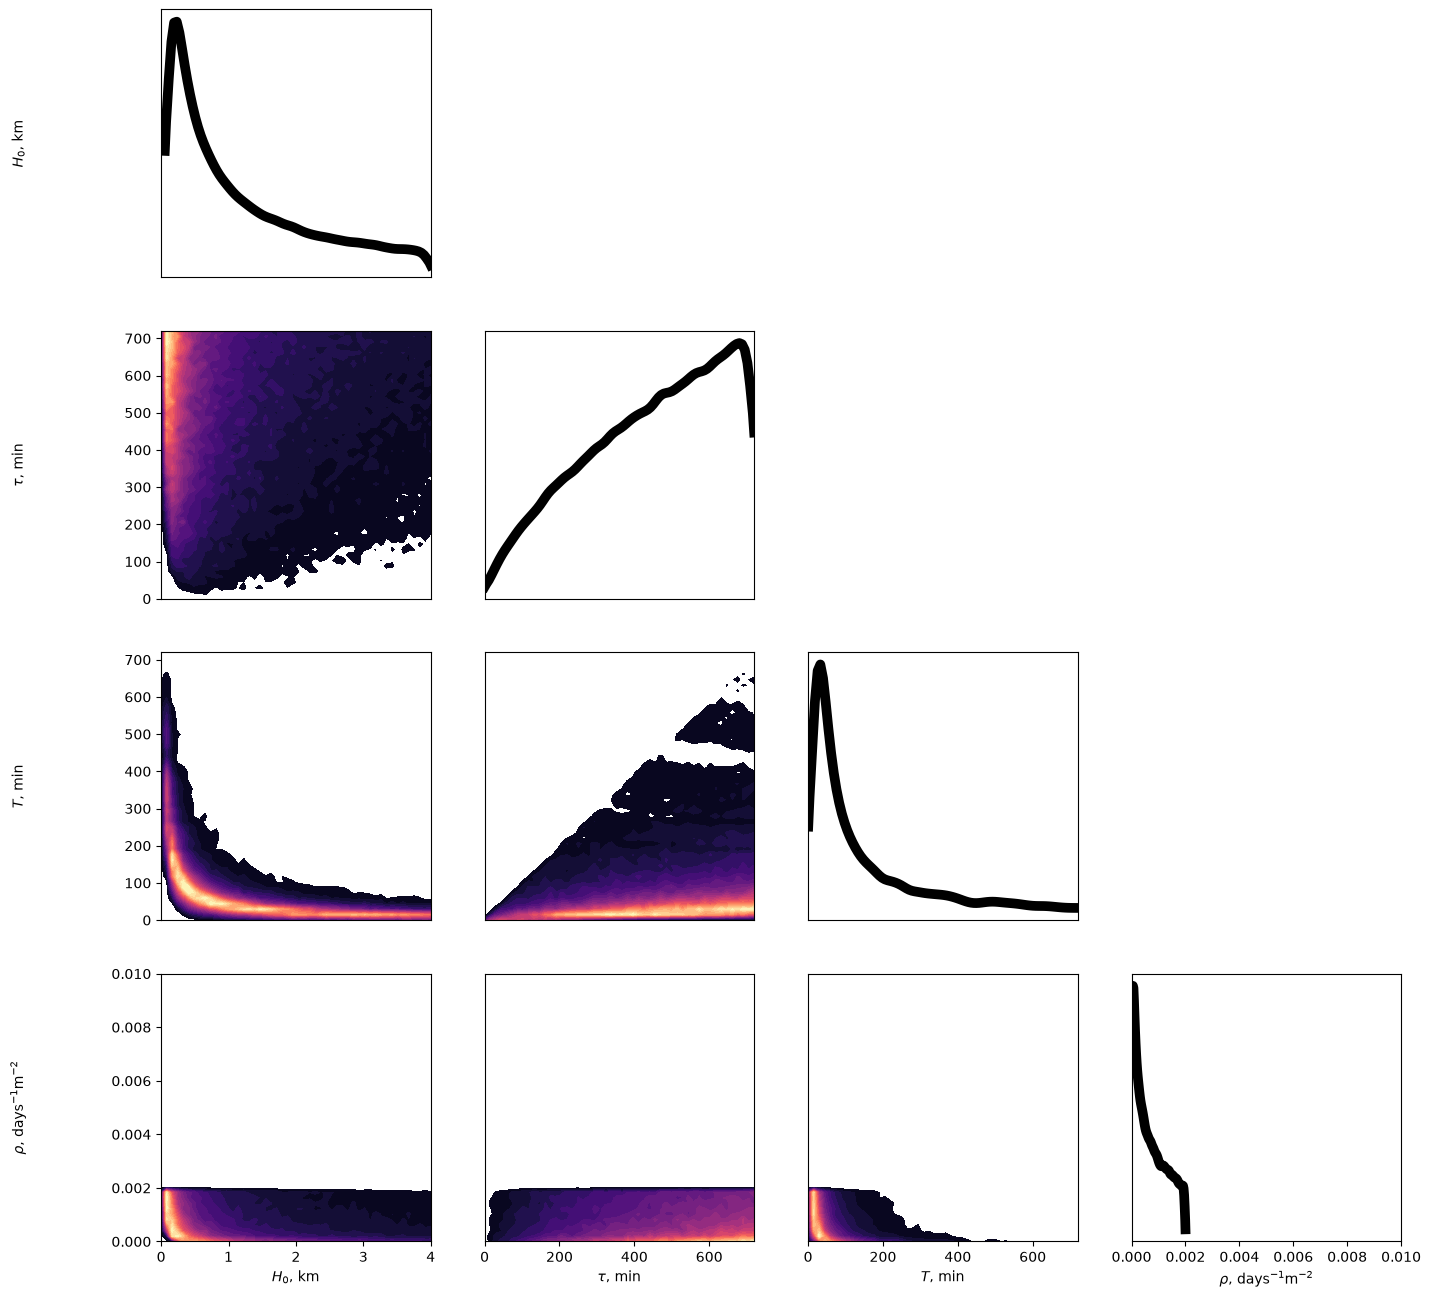

In [7]:
PlotClouds.contours(plot_concat, cmap_hist= newcmp ,linewidth= 7,fill_contours = True ,nLevels = 25,
                     bounds = [[0,4],[0,720],[0,720],[0, 1e-2]],nBins = 50, labels = 
                   ['$H_0$, km','$\\tau$, min','$T$, min','$\\rho$, days${}^{-1}$m${}^{-2}$'])

plt.show()